<a href="https://colab.research.google.com/github/Owais-SciML/1webopsbc/blob/projects/gan_airfoil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

Step 1: Initialize the Environment & Generate the Dataset:

We will generate 2,000 distinct airfoils by varying the camber, maximum camber position, and thickness parameters using the standard NACA 4-digit mathematical equations. Each airfoil will be represented as a 1D array of 64 coordinate points (32 upper, 32 lower).

In [ ]:
# 1. NACA 4-Digit Airfoil Generator Function
def generate_naca4(m, p, t, n_points=32):
    x = np.linspace(0, 1, n_points)
    # Thickness distribution
    yt = 5 * t * (0.2969*np.sqrt(x) - 0.1260*x - 0.3516*x**2 + 0.2843*x**3 - 0.1015*x**4)

    # Camber line
    yc = np.zeros_like(x)
    if p > 0:
        idx1 = x <= p
        idx2 = x > p
        if p > 0: yc[idx1] = (m / p**2) * (2*p*x[idx1] - x[idx1]**2)
        if p < 1: yc[idx2] = (m / (1-p)**2) * ((1-2*p) + 2*p*x[idx2] - x[idx2]**2)

    # Upper and lower surfaces
    y_upper = yc + yt
    y_lower = yc - yt
    # Combine into a single 1D vector of 64 features (y-coordinates)
    return np.concatenate([y_upper, y_lower])


















# 2. Build a diverse dataset of 2,000 airfoils

dataset = []
for m in np.linspace(0.0, 0.06, 10):
    for p in np.linspace(0.2, 0.6, 10):
        for t in np.linspace(0.05, 0.18, 20):
            dataset.append(generate_naca4(m, p, t))

dataset = np.array(dataset, dtype=np.float32)
print(f"Dataset shape:  {dataset.shape}")
print(f"Raw data range: [{dataset.min():.4f}, {dataset.max():.4f}]")

# ── KEY FIX: real airfoil y-values are ~[-0.15, 0.25] but
#    Generator's Tanh outputs [-1, 1].  This mismatch is why
#    D Loss locked at 2×ln(2) ≈ 1.386 (discriminator guesses 50/50).
data_min  = dataset.min(axis=0)
data_scale = dataset.max(axis=0) - data_min
data_scale[data_scale == 0] = 1.0          # avoid div-by-zero
dataset_norm = 2.0 * (dataset - data_min) / data_scale - 1.0

print(f"Normalized range: [{dataset_norm.min():.3f}, {dataset_norm.max():.3f}]")

# Store params for inverse-transform when plotting
norm_params = {"min": data_min, "scale": data_scale}

dataset_tensor = torch.tensor(dataset_norm)
# FIX: larger batch → more stable gradient estimates
dataloader = DataLoader(TensorDataset(dataset_tensor),
                        batch_size=64, shuffle=True)


Dataset shape:  (2000, 64)
Raw data range: [-0.0900, 0.1500]
Normalized range: [-1.000, 1.000]


Step 2: Define the Generator and Discriminator:

The Generator takes a vector of random noise (latent space) and maps it to a 64-element array (the airfoil shape). The Discriminator takes a 64-element array and classifies whether it looks like a real structural airfoil or random noise.

In [ ]:
latent_dim  = 16   # FIX: larger latent space (was 10)
airfoil_dim = 64

class Generator(nn.Module):
    """5-layer net with BatchNorm for stable gradients.
       Previous 3-layer version couldn't learn complex shapes."""
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, airfoil_dim),
            nn.Tanh()   # output in [-1, 1] — NOW matches normalized data
        )

    def forward(self, z):
        return self.model(z)


class Discriminator(nn.Module):
    """Deeper Discriminator with Dropout(0.3) to prevent memorization
       and keep it a useful learning signal for the Generator."""
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(airfoil_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator     = Generator().to(device)
discriminator = Discriminator().to(device)
print(f"\nDevice: {device}")
print(f"Generator params:     {sum(p.numel() for p in generator.parameters()):,}")
print(f"Discriminator params: {sum(p.numel() for p in discriminator.parameters()):,}")


Device: cpu
Generator params:     84,736
Discriminator params: 57,857


Step 3: Define Loss and Optimizers:

We use Binary Cross-Entropy Loss (BCELoss) because the discriminator is solving a binary classification problem (Real = 1, Fake = 0).

In [ ]:
criterion   = nn.BCELoss()

# Generator needs 2× the LR of Discriminator so it can keep up
optimizer_G = optim.Adam(generator.parameters(),
                         lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(),
                         lr=0.0001, betas=(0.5, 0.999))   # half of G's LR

Step 4: The Training Loop:

This loop runs for 200 epochs. On Colab’s T4 GPU (takes time)

In [ ]:
epochs   = 500
d_losses = []
g_losses = []

for epoch in range(epochs):
    d_epoch, g_epoch = [], []

    for (real_airfoils,) in dataloader:
        bs = real_airfoils.size(0)
        real_airfoils = real_airfoils.to(device)

        # FIX #5a — Label smoothing: real labels drawn from U(0.85, 1.0)
        # instead of hard 1.0.  Prevents Discriminator becoming over-confident
        # and saturating the Generator's gradient to zero.
        real_labels = torch.empty(bs, 1).uniform_(0.85, 1.0).to(device)
        fake_labels = torch.zeros(bs, 1).to(device)

        # ── Train Discriminator (once per batch) ──────────────
        optimizer_D.zero_grad()

        d_real = criterion(discriminator(real_airfoils), real_labels)

        z    = torch.randn(bs, latent_dim).to(device)
        fake = generator(z).detach()          # detach: don't train G yet
        d_fake = criterion(discriminator(fake), fake_labels)

        d_loss = d_real + d_fake
        d_loss.backward()
        optimizer_D.step()

        # ── Train Generator (2× per D step) — FIX #5b ────────
        # Generator needs more updates to keep up with Discriminator
        for _ in range(2):
            optimizer_G.zero_grad()
            z    = torch.randn(bs, latent_dim).to(device)
            fake = generator(z)
            # Generator wants D to output 1.0 for fake samples
            g_loss = criterion(discriminator(fake),
                               torch.ones(bs, 1).to(device))
            g_loss.backward()
            optimizer_G.step()

        d_epoch.append(d_loss.item())
        g_epoch.append(g_loss.item())

    d_losses.append(np.mean(d_epoch))
    g_losses.append(np.mean(g_epoch))

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1:>3}/{epochs}] | "
              f"D Loss: {d_losses[-1]:.4f} | G Loss: {g_losses[-1]:.4f}")

Epoch [ 20/500] | D Loss: 1.3805 | G Loss: 0.7707
Epoch [ 40/500] | D Loss: 1.3792 | G Loss: 0.7711
Epoch [ 60/500] | D Loss: 1.3791 | G Loss: 0.7751
Epoch [ 80/500] | D Loss: 1.3752 | G Loss: 0.7749
Epoch [100/500] | D Loss: 1.3692 | G Loss: 0.7859
Epoch [120/500] | D Loss: 1.3616 | G Loss: 0.7977
Epoch [140/500] | D Loss: 1.3326 | G Loss: 0.8229
Epoch [160/500] | D Loss: 1.2924 | G Loss: 0.8721
Epoch [180/500] | D Loss: 1.2096 | G Loss: 0.9855
Epoch [200/500] | D Loss: 1.1681 | G Loss: 1.0912
Epoch [220/500] | D Loss: 1.1314 | G Loss: 1.1727
Epoch [240/500] | D Loss: 1.0772 | G Loss: 1.3026
Epoch [260/500] | D Loss: 1.0523 | G Loss: 1.3618
Epoch [280/500] | D Loss: 1.0763 | G Loss: 1.4408
Epoch [300/500] | D Loss: 1.0224 | G Loss: 1.5443
Epoch [320/500] | D Loss: 0.9998 | G Loss: 1.4898
Epoch [340/500] | D Loss: 1.0595 | G Loss: 1.5351
Epoch [360/500] | D Loss: 1.0683 | G Loss: 1.5650
Epoch [380/500] | D Loss: 0.9595 | G Loss: 1.6718
Epoch [400/500] | D Loss: 0.9917 | G Loss: 1.6643


Step 6: Loss Curves

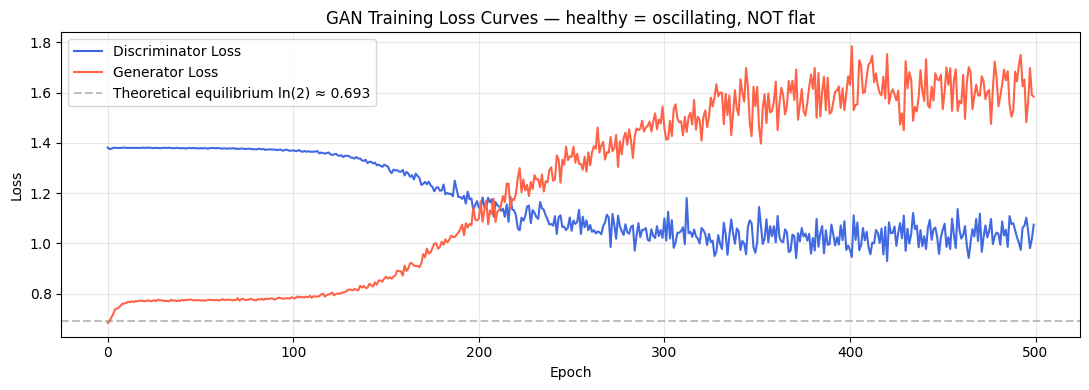

In [ ]:
plt.figure(figsize=(11, 4))
plt.plot(d_losses, label="Discriminator Loss", color="royalblue", linewidth=1.5)
plt.plot(g_losses, label="Generator Loss",     color="tomato",    linewidth=1.5)
plt.axhline(np.log(2), color="gray", linestyle="--", alpha=0.5,
            label=f"Theoretical equilibrium ln(2) ≈ {np.log(2):.3f}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Loss Curves — healthy = oscillating, NOT flat")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Step 7: Generate and denormalize Airfoil

In [ ]:
def denormalize(x_norm):
    """Invert the [-1, 1] normalization back to real chord coordinates."""
    return 0.5 * (x_norm + 1) * norm_params["scale"] + norm_params["min"]

generator.eval()
with torch.no_grad():
    z        = torch.randn(5, latent_dim).to(device)
    gen_norm = generator(z).cpu().numpy()
    generated_shapes = denormalize(gen_norm)   # back to real y/c units

Step 5: Plot generated Airfols

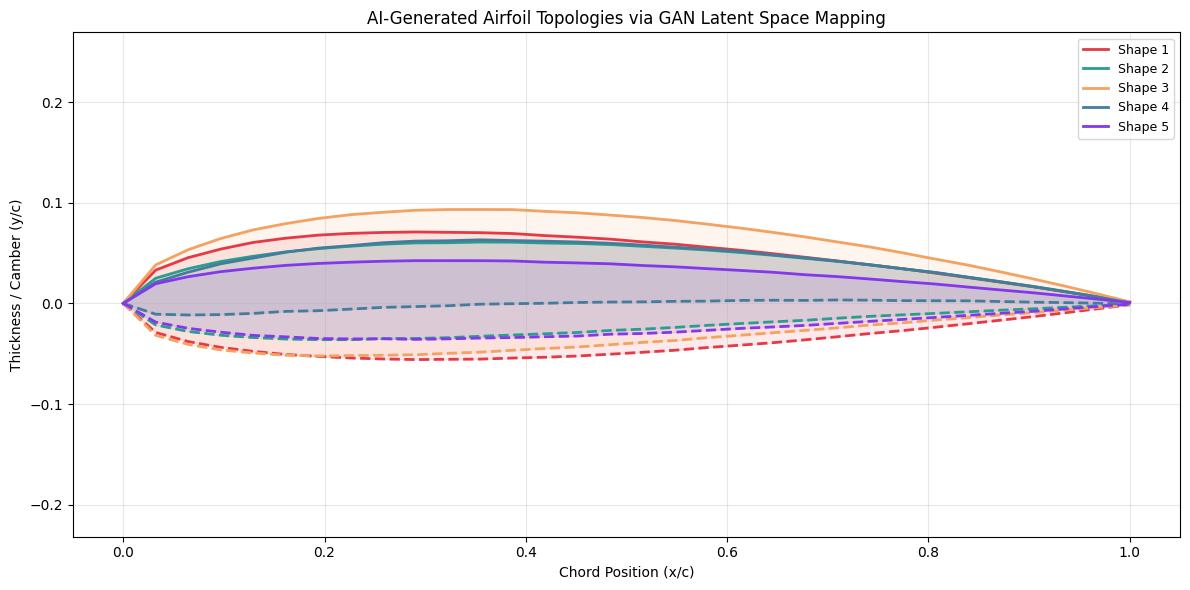

In [ ]:
colors   = ["#e63946", "#2a9d8f", "#f4a261", "#457b9d", "#8338ec"]
x_coords = np.linspace(0, 1, 32)

plt.figure(figsize=(12, 6))
for idx in range(5):
    airfoil = generated_shapes[idx]
    y_upper = airfoil[:32]
    y_lower = airfoil[32:]
    plt.fill_between(x_coords, y_lower, y_upper,
                     alpha=0.10, color=colors[idx])
    plt.plot(x_coords, y_upper, color=colors[idx],
             linewidth=2, label=f"Shape {idx+1}")
    plt.plot(x_coords, y_lower, color=colors[idx],
             linewidth=2, linestyle="--")

plt.title("AI-Generated Airfoil Topologies via GAN Latent Space Mapping")
plt.xlabel("Chord Position (x/c)")
plt.ylabel("Thickness / Camber (y/c)")
plt.legend(loc="upper right", fontsize=9)
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.tight_layout()
plt.show()

Dataset generated successfully! Shape: (2000, 64)
Models initialized and pushed to device: cpu
Epoch [20/200] | D Loss: 1.3810 | G Loss: 0.6944
Epoch [40/200] | D Loss: 1.3827 | G Loss: 0.6968
Epoch [60/200] | D Loss: 1.3862 | G Loss: 0.6988
Epoch [80/200] | D Loss: 1.3879 | G Loss: 0.6922
Epoch [100/200] | D Loss: 1.3792 | G Loss: 0.6490
Epoch [120/200] | D Loss: 1.3929 | G Loss: 0.6813
Epoch [140/200] | D Loss: 1.3916 | G Loss: 0.6831
Epoch [160/200] | D Loss: 1.3966 | G Loss: 0.6985
Epoch [180/200] | D Loss: 1.3703 | G Loss: 0.6987
Epoch [200/200] | D Loss: 1.3827 | G Loss: 0.6890


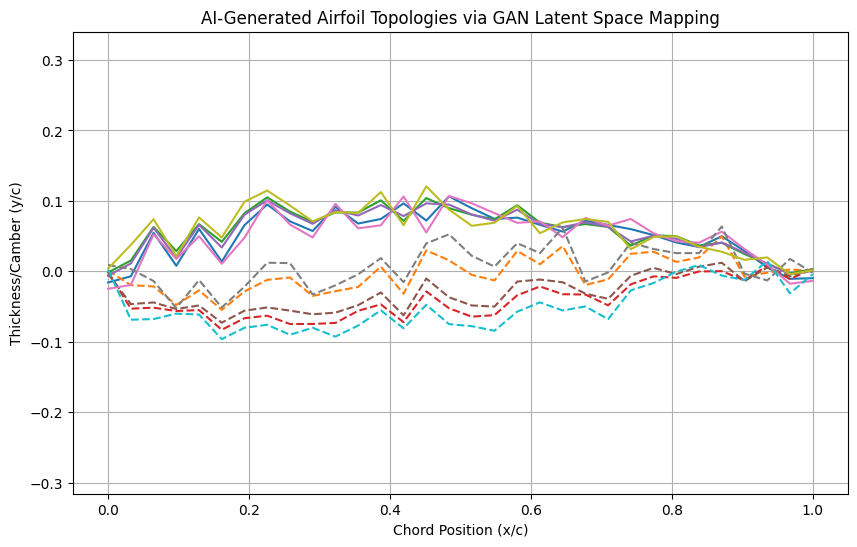

In [ ]:
# My Rough Code


#step 1:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
# 1. NACA 4-Digit Airfoil Generator Function
def generate_naca4(m, p, t, n_points=32):
    x = np.linspace(0, 1, n_points)
    # Thickness distribution
    yt = 5 * t * (0.2969*np.sqrt(x) - 0.1260*x - 0.3516*x**2 + 0.2843*x**3 - 0.1015*x**4)

    # Camber line
    yc = np.zeros_like(x)
    if p > 0:
        idx1 = x <= p
        idx2 = x > p
        if p > 0: yc[idx1] = (m / p**2) * (2*p*x[idx1] - x[idx1]**2)
        if p < 1: yc[idx2] = (m / (1-p)**2) * ((1-2*p) + 2*p*x[idx2] - x[idx2]**2)

    # Upper and lower surfaces
    y_upper = yc + yt
    y_lower = yc - yt
    # Combine into a single 1D vector of 64 features (y-coordinates)
    return np.concatenate([y_upper, y_lower])
# 2. Build a diverse dataset of 2,000 airfoils
dataset = []
for m in np.linspace(0.0, 0.06, 10):       # Max camber
    for p in np.linspace(0.2, 0.6, 10):    # Position of max camber
        for t in np.linspace(0.05, 0.18, 20): # Thickness
            dataset.append(generate_naca4(m, p, t))
dataset = np.array(dataset, dtype=np.float32)
print(f"Dataset generated successfully! Shape: {dataset.shape}")
# Convert to PyTorch Dataloader
dataset_tensor = torch.tensor(dataset)
dataloader = DataLoader(TensorDataset(dataset_tensor), batch_size=32, shuffle=True)





#2
latent_dim = 10
airfoil_dim = 64
# Generator Network
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, airfoil_dim),
            nn.Tanh() # Normalizes output shape bounds
        )
    def forward(self, z):
        return self.model(z)
# Discriminator Network
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(airfoil_dim, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid() # Outputs probability of "Real" vs "Fake"
        )
    def forward(self, x):
        return self.model(x)
# Instantiate models and move to Colab GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = Generator().to(device)
discriminator = Discriminator().to(device)
print(f"Models initialized and pushed to device: {device}")





#3
criterion = nn.BCELoss()
lr = 0.0002
optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))



#4
epochs = 200
for epoch in range(epochs):
    for i, (real_airfoils,) in enumerate(dataloader):
        batch_size = real_airfoils.size(0)
        real_airfoils = real_airfoils.to(device)

        # Ground truth labels
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # ---------------------
        #  Train Discriminator
        # ---------------------
        optimizer_D.zero_grad()

        # Loss on real airfoils
        outputs = discriminator(real_airfoils)
        d_loss_real = criterion(outputs, real_labels)

        # Loss on generated (fake) airfoils
        z = torch.randn(batch_size, latent_dim).to(device)
        fake_airfoils = generator(z)
        outputs = discriminator(fake_airfoils.detach())
        d_loss_fake = criterion(outputs, fake_labels)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_D.step()

        # -----------------
        #  Train Generator
        # -----------------
        optimizer_G.zero_grad()

        outputs = discriminator(fake_airfoils)
        g_loss = criterion(outputs, real_labels) # Generator wants fake to be classified as real

        g_loss.backward()
        optimizer_G.step()

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")




#5
# Generate 5 novel airfoils
generator.eval()
with torch.no_grad():
    random_noise = torch.randn(5, latent_dim).to(device)
    generated_shapes = generator(random_noise).cpu().numpy()
# Plot the generated airfoils
plt.figure(figsize=(10, 6))
x_coords = np.linspace(0, 1, 32)
for idx in range(5):
    airfoil = generated_shapes[idx]
    y_upper = airfoil[:32]
    y_lower = airfoil[32:]

    plt.plot(x_coords, y_upper, label=f'Gen {idx+1} Upper')
    plt.plot(x_coords, y_lower, linestyle='--', label=f'Gen {idx+1} Lower')
plt.title("AI-Generated Airfoil Topologies via GAN Latent Space Mapping")
plt.xlabel("Chord Position (x/c)")
plt.ylabel("Thickness/Camber (y/c)")
plt.grid(True)
plt.axis('equal')
plt.show()